## Install necessary dependencies and import libraries

In [ ]:
%pip install pandas matplotlib seaborn geopandas folium requests openpyxl shapely matplotlib-scalebar adjustText

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib_scalebar.scalebar import ScaleBar
import seaborn as sns
import geopandas as gpd
import folium
from folium.plugins import MeasureControl
import requests
import json
from pathlib import Path
from shapely.geometry import Point

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "font.family": "sans-serif",
})

DATA_DIR = Path("data")
OUT_DIR = Path("outputs")
DATA_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

## Tasks 1 & 2 — Location Map and District Overview

In [3]:
# --- Download GADM admin boundaries (levels 0, 1, 2) ---
GADM_BASE = "https://geodata.ucdavis.edu/gadm/gadm4.1/json"

gadm_paths = {}
for lvl in (0, 1, 2):
    local = DATA_DIR / f"gadm41_UZB_{lvl}.json"
    if not local.exists():
        url = f"{GADM_BASE}/gadm41_UZB_{lvl}.json"
        print(f"Downloading {url} …")
        r = requests.get(url, timeout=60)
        r.raise_for_status()
        local.write_text(r.text, encoding="utf-8")
    gadm_paths[lvl] = local

uzb_country = gpd.read_file(gadm_paths[0])
uzb_regions = gpd.read_file(gadm_paths[1])
uzb_districts = gpd.read_file(gadm_paths[2])

navoi_region = uzb_regions[uzb_regions["NAME_1"].str.contains("Navoi", case=False)]
khatirchi = uzb_districts[uzb_districts["NAME_2"].str.contains("Xatirchi|Khatirchi|Khatyrchi", case=False)]

print(f"Country: {len(uzb_country)} | Regions: {len(uzb_regions)} | Districts: {len(uzb_districts)}")
print(f"Navoi: {len(navoi_region)} feature(s) | Khatirchi: {len(khatirchi)} feature(s)")
print("Khatirchi columns:", khatirchi[["NAME_1", "NAME_2"]].values.tolist())

Country: 1 | Regions: 14 | Districts: 161
Navoi: 1 feature(s) | Khatirchi: 1 feature(s)
Khatirchi columns: [['Navoiy', 'Xatirchi']]


/var/folders/mq/_sqb9c5d6_qbyy9r564mz9jh0000gn/T/ipykernel_24355/841815331.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  navoi_centroid = navoi_region.geometry.centroid.iloc[0]


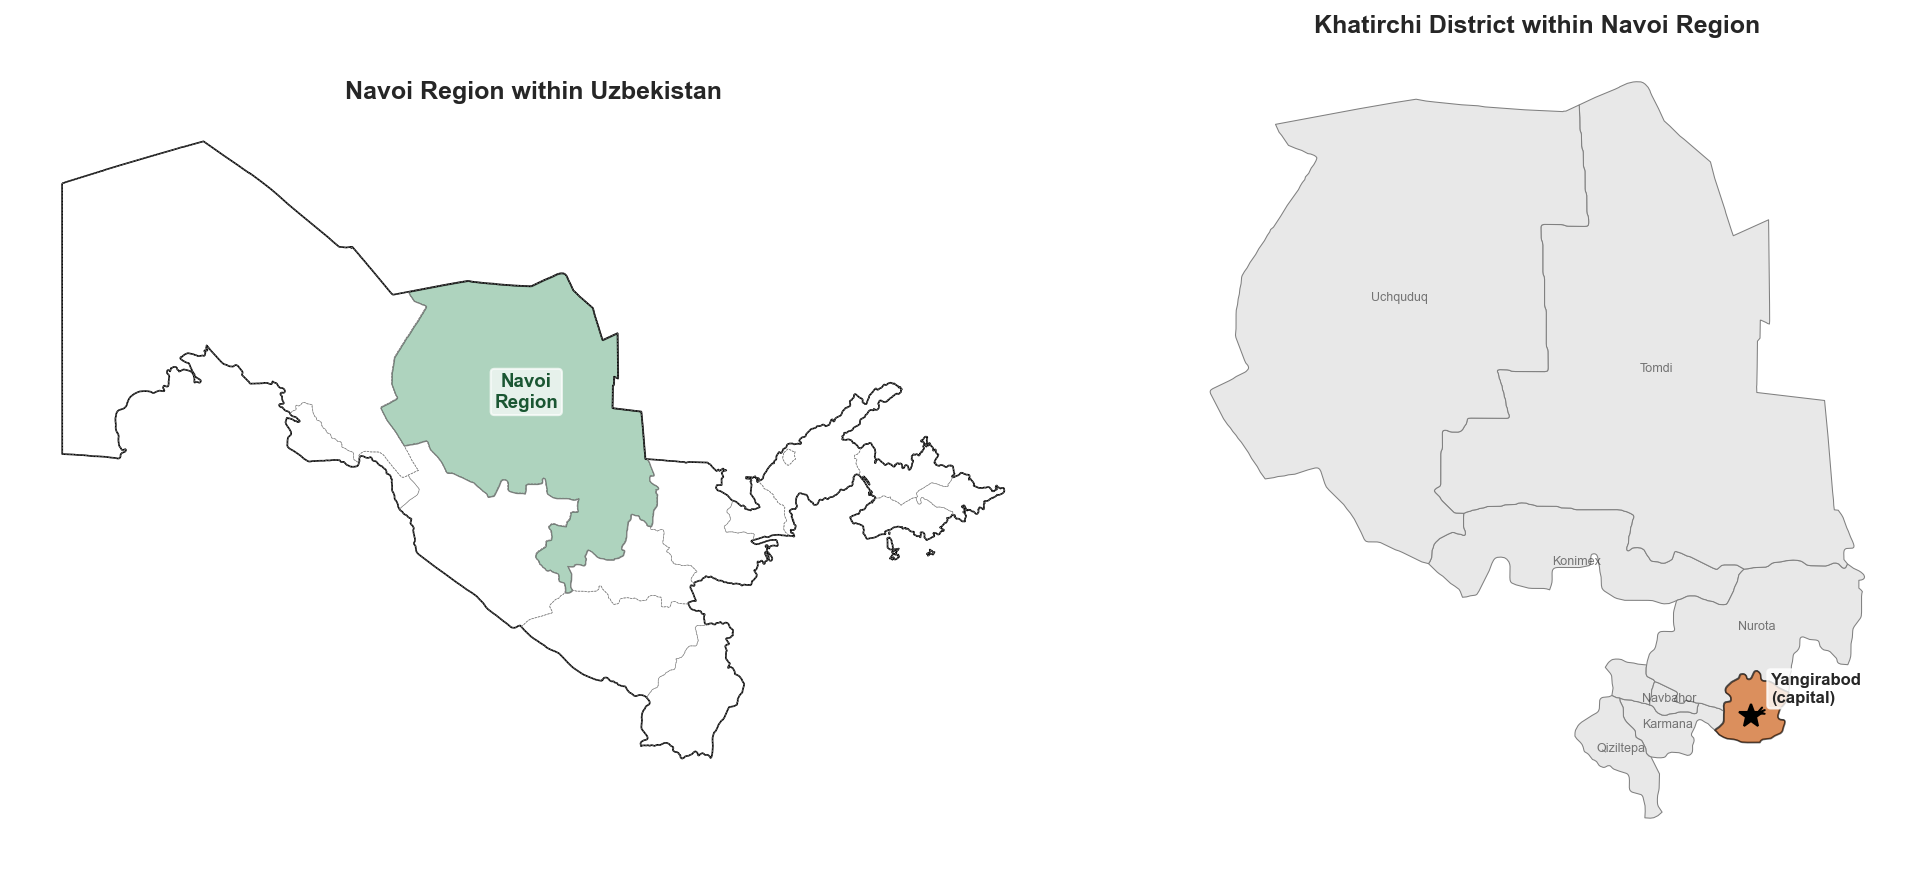

In [4]:
# --- Location map: Uzbekistan → Navoi → Khatirchi ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left panel – Uzbekistan with Navoi highlighted
ax1 = axes[0]
uzb_country.boundary.plot(ax=ax1, color="black", linewidth=0.8)
uzb_regions.boundary.plot(ax=ax1, color="grey", linewidth=0.3, linestyle="--")
navoi_region.plot(ax=ax1, color="#4C9F70", alpha=0.45, edgecolor="black", linewidth=0.6)
navoi_centroid = navoi_region.geometry.centroid.iloc[0]
ax1.annotate("Navoi\nRegion", xy=(navoi_centroid.x, navoi_centroid.y),
             fontsize=9, fontweight="bold", ha="center", color="#1a5632",
             bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))
ax1.set_title("Navoi Region within Uzbekistan", fontsize=12, fontweight="bold")
ax1.set_axis_off()

# Right panel – Navoi Region with Khatirchi highlighted
ax2 = axes[1]
navoi_districts = uzb_districts[uzb_districts["NAME_1"].str.contains("Navoi", case=False)]
navoi_districts.plot(ax=ax2, color="#e8e8e8", edgecolor="grey", linewidth=0.5)
khatirchi.plot(ax=ax2, color="#D35400", alpha=0.6, edgecolor="black", linewidth=0.8)

yangirabad = Point(65.965, 40.037)
ax2.plot(yangirabad.x, yangirabad.y, marker="*", color="black", markersize=12, zorder=5)
ax2.annotate("Yangirabod\n(capital)", xy=(yangirabad.x, yangirabad.y),
             xytext=(yangirabad.x + 0.15, yangirabad.y + 0.08),
             fontsize=8, fontweight="bold",
             arrowprops=dict(arrowstyle="->", color="black"),
             bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8))

for _, row in navoi_districts.iterrows():
    c = row.geometry.centroid
    label = row["NAME_2"]
    if "Xatirchi" in label or "Khatirchi" in label:
        continue
    ax2.annotate(label, xy=(c.x, c.y), fontsize=6, ha="center", alpha=0.6)

ax2.set_title("Khatirchi District within Navoi Region", fontsize=12, fontweight="bold")
ax2.set_axis_off()

plt.tight_layout()
plt.savefig(OUT_DIR / "task1_location_map.png")
plt.show()

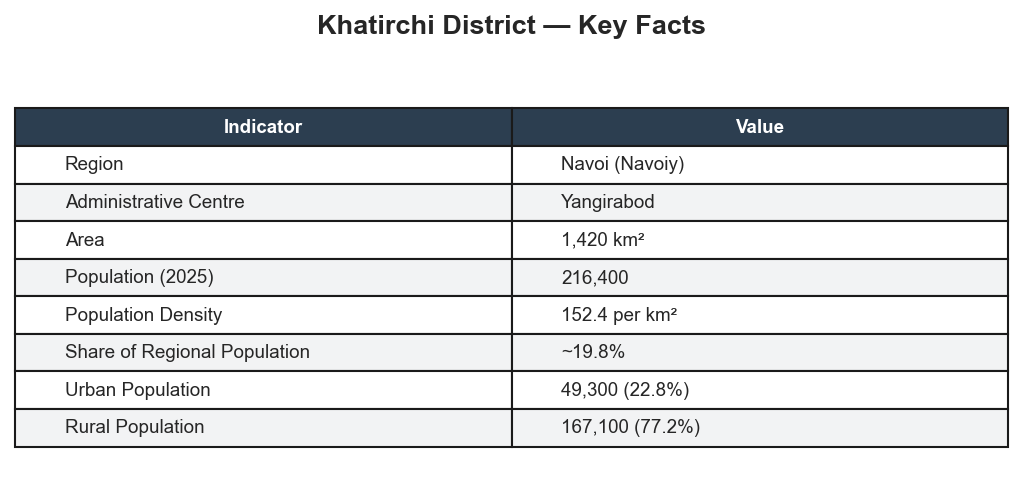

In [5]:
# --- District fact sheet table ---
facts = pd.DataFrame({
    "Indicator": [
        "Region", "Administrative Centre", "Area",
        "Population (2025)", "Population Density",
        "Share of Regional Population", "Urban Population",
        "Rural Population",
    ],
    "Value": [
        "Navoi (Navoiy)", "Yangirabod", "1,420 km²",
        "216,400", "152.4 per km²", "~19.8%",
        "49,300 (22.8%)", "167,100 (77.2%)",
    ],
})

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.axis("off")
tbl = ax.table(cellText=facts.values, colLabels=facts.columns,
               cellLoc="left", loc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.5)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor("#2C3E50")
        cell.set_text_props(color="white", fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#F2F3F4")
ax.set_title("Khatirchi District — Key Facts", fontsize=13, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig(OUT_DIR / "task2_fact_sheet.png")
plt.show()

## Task 3 — Environmental and Climate Note

Monthly temperature and precipitation normals for Navoi / Khatirchi area.
Sources: weather-and-climate.com, World Bank Climate Change Knowledge Portal.

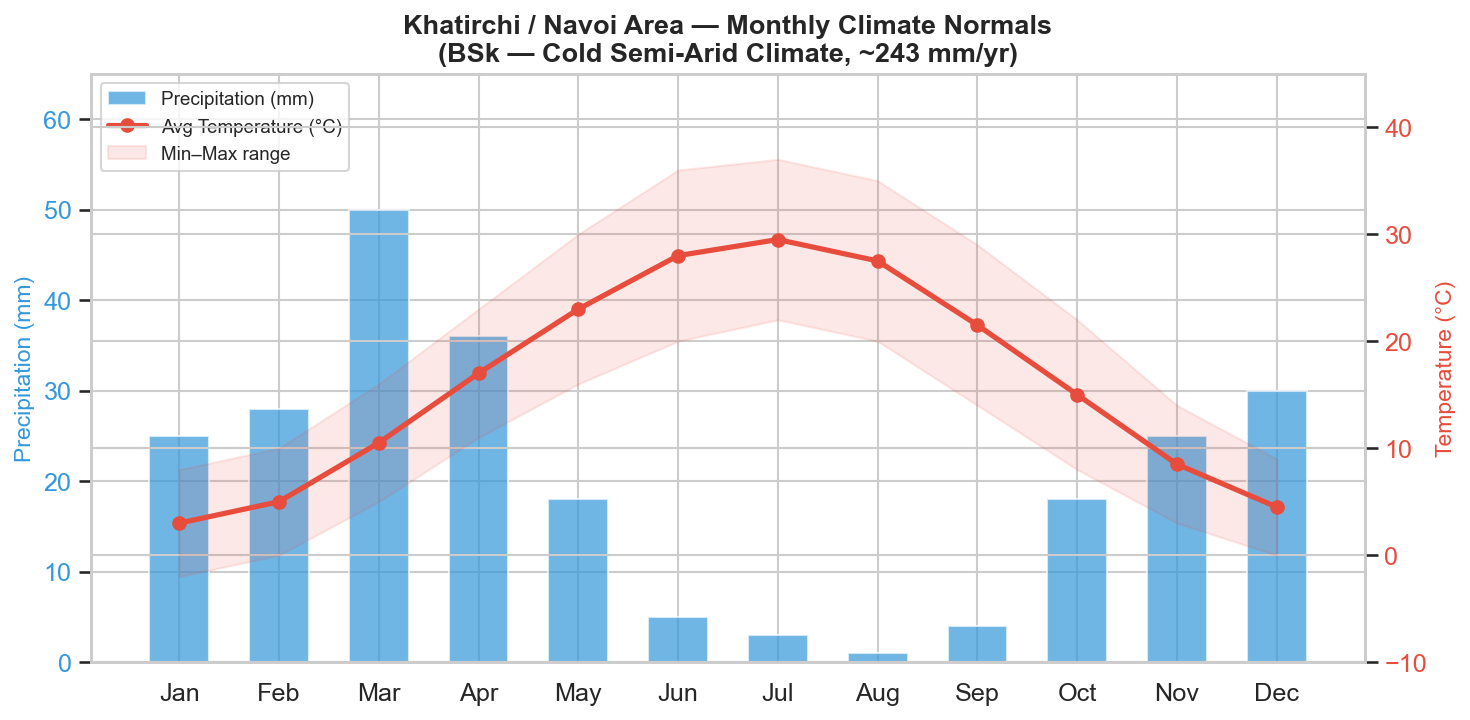

In [6]:
# --- Task 3: Climate chart (dual-axis) ---
climate = pd.read_csv(DATA_DIR / "climate_normals.csv")

fig, ax1 = plt.subplots(figsize=(10, 5))

bar_color = "#3498DB"
line_color = "#E74C3C"

ax1.bar(climate["month_name"], climate["precip_mm"], color=bar_color, alpha=0.7,
        label="Precipitation (mm)", width=0.6, zorder=2)
ax1.set_ylabel("Precipitation (mm)", color=bar_color, fontsize=11)
ax1.set_ylim(0, 65)
ax1.tick_params(axis="y", labelcolor=bar_color)

ax2 = ax1.twinx()
ax2.plot(climate["month_name"], climate["avg_temp_c"], color=line_color,
         marker="o", linewidth=2.5, markersize=6, label="Avg Temperature (°C)", zorder=3)
ax2.fill_between(climate["month_name"], climate["min_temp_c"], climate["max_temp_c"],
                 alpha=0.12, color=line_color, label="Min–Max range")
ax2.set_ylabel("Temperature (°C)", color=line_color, fontsize=11)
ax2.set_ylim(-10, 45)
ax2.tick_params(axis="y", labelcolor=line_color)

ax1.set_xlabel("")
ax1.set_title("Khatirchi / Navoi Area — Monthly Climate Normals\n"
              "(BSk — Cold Semi-Arid Climate, ~243 mm/yr)",
              fontsize=13, fontweight="bold")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / "task3_climate.png")
plt.show()

## Task 4 — Demography and Urbanization Trends

Population growth 2015–2025, urban/rural split, age structure.
Sources: navstat.uz, stat.uz, Wikipedia.

In [7]:
# --- Load population data ---
pop_kh = pd.read_csv(DATA_DIR / "population_khatirchi.csv")
pop_nv = pd.read_csv(DATA_DIR / "population_navoi.csv")

pop = pop_kh[["year", "population"]].merge(
    pop_nv[["year", "population"]], on="year", suffixes=("_kh", "_nv")
)

# Indexed to 2015 = 100 for fair comparison
pop["kh_idx"] = pop["population_kh"] / pop["population_kh"].iloc[0] * 100
pop["nv_idx"] = pop["population_nv"] / pop["population_nv"].iloc[0] * 100

# CAGR
years_span = pop["year"].iloc[-1] - pop["year"].iloc[0]
cagr_kh = ((pop["population_kh"].iloc[-1] / pop["population_kh"].iloc[0]) ** (1 / years_span) - 1) * 100
cagr_nv = ((pop["population_nv"].iloc[-1] / pop["population_nv"].iloc[0]) ** (1 / years_span) - 1) * 100
print(f"Khatirchi CAGR 2015–2025: {cagr_kh:.2f}%")
print(f"Navoi Region CAGR 2015–2025: {cagr_nv:.2f}%")
print(f"Khatirchi share of Navoi (2025): {pop['population_kh'].iloc[-1] / pop['population_nv'].iloc[-1] * 100:.1f}%")

Khatirchi CAGR 2015–2025: 1.69%
Navoi Region CAGR 2015–2025: 1.67%
Khatirchi share of Navoi (2025): 19.8%


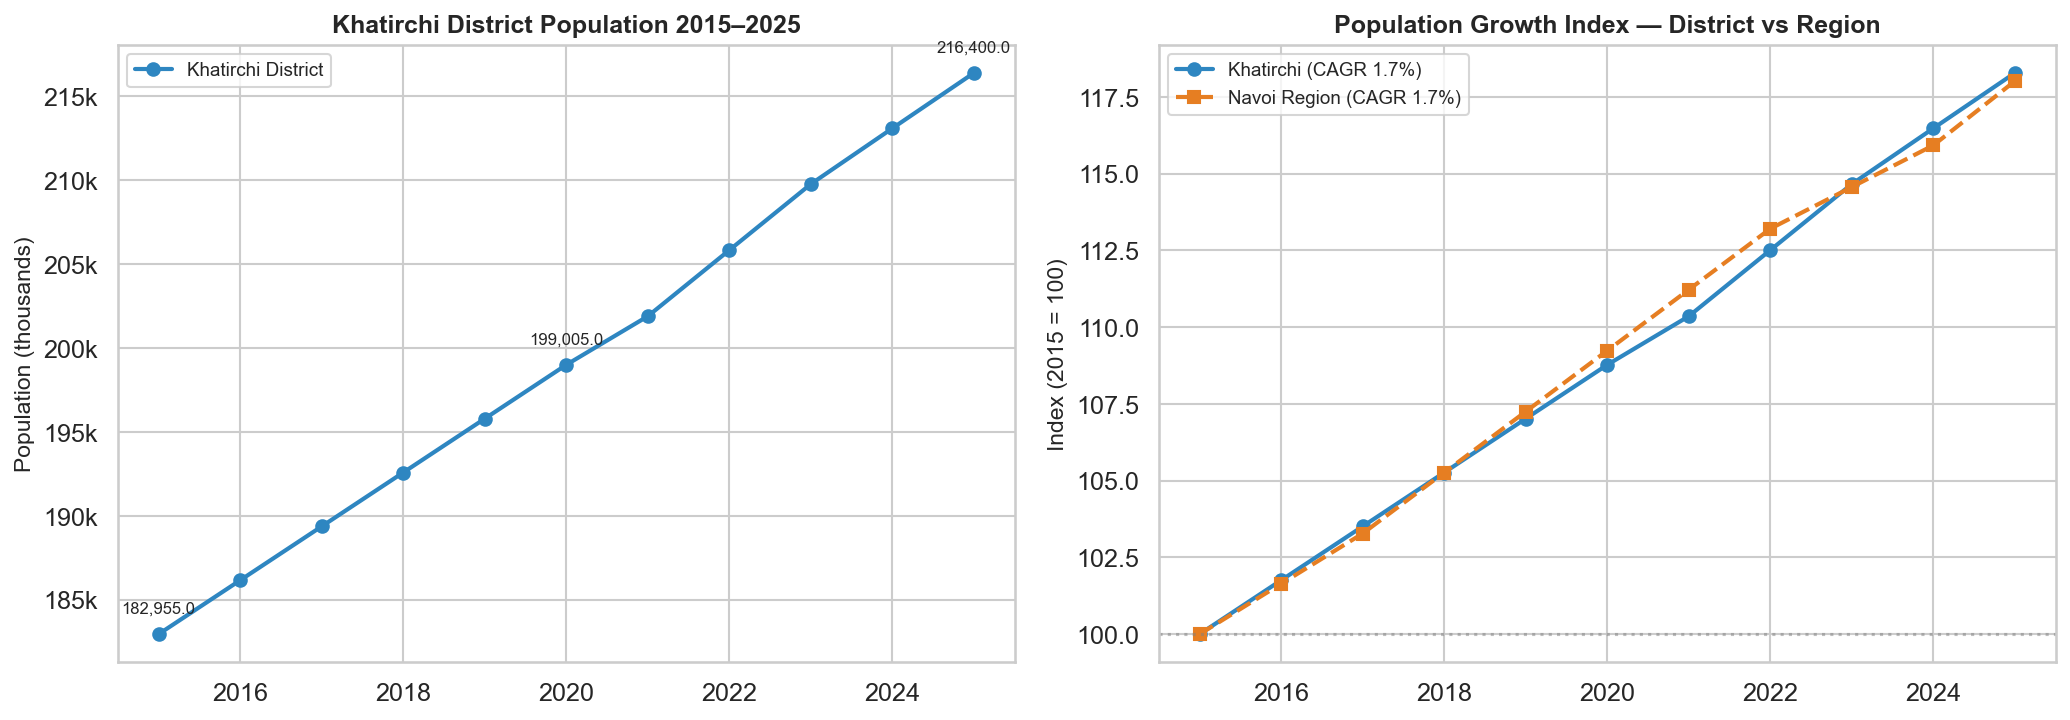

In [8]:
# --- Chart 1: Population growth — Khatirchi vs Navoi Region (indexed) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: absolute numbers
ax1.plot(pop["year"], pop["population_kh"] / 1000, "o-", color="#2E86C1", linewidth=2, label="Khatirchi District")
ax1.set_ylabel("Population (thousands)", fontsize=11)
ax1.set_xlabel("")
ax1.set_title("Khatirchi District Population 2015–2025", fontsize=12, fontweight="bold")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}k"))
for i, row in pop.iterrows():
    if row["year"] in (2015, 2020, 2025):
        ax1.annotate(f"{row['population_kh']:,}", (row["year"], row["population_kh"] / 1000),
                     textcoords="offset points", xytext=(0, 10), fontsize=8, ha="center")
ax1.legend(fontsize=9)

# Right: indexed comparison
ax2.plot(pop["year"], pop["kh_idx"], "o-", color="#2E86C1", linewidth=2, label=f"Khatirchi (CAGR {cagr_kh:.1f}%)")
ax2.plot(pop["year"], pop["nv_idx"], "s--", color="#E67E22", linewidth=2, label=f"Navoi Region (CAGR {cagr_nv:.1f}%)")
ax2.axhline(100, color="grey", linestyle=":", alpha=0.5)
ax2.set_ylabel("Index (2015 = 100)", fontsize=11)
ax2.set_title("Population Growth Index — District vs Region", fontsize=12, fontweight="bold")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / "task4_population_growth.png")
plt.show()

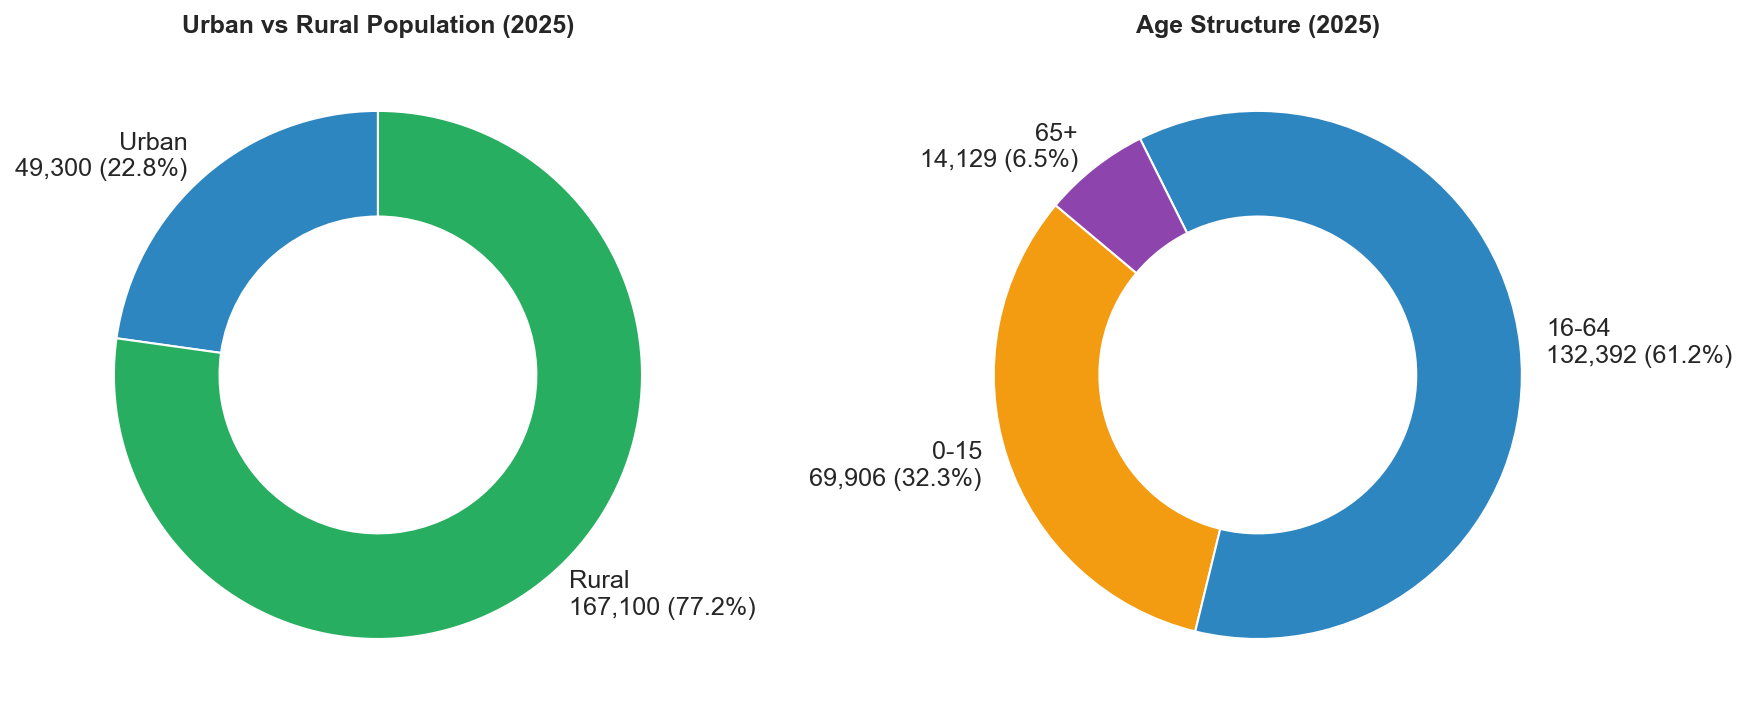

Youth dependency (0-15 as % of 16-64): 52.8%
Old-age dependency (65+ as % of 16-64): 10.7%


In [9]:
# --- Chart 2: Urban vs Rural split & Chart 3: Age structure ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Urban / Rural donut
urban, rural = 49_300, 167_100
sizes = [urban, rural]
labels = [f"Urban\n{urban:,} (22.8%)", f"Rural\n{rural:,} (77.2%)"]
colors = ["#2E86C1", "#27AE60"]
wedges, texts, autotexts = ax1.pie(
    sizes, labels=labels, colors=colors, autopct="",
    startangle=90, pctdistance=0.75, wedgeprops=dict(width=0.4, edgecolor="white")
)
ax1.set_title("Urban vs Rural Population (2025)", fontsize=12, fontweight="bold")

# Age structure
age = pd.read_csv(DATA_DIR / "age_structure.csv")
colors_age = ["#F39C12", "#2E86C1", "#8E44AD"]
wedges2, texts2, autotexts2 = ax2.pie(
    age["population"], labels=[f"{r['age_group']}\n{r['population']:,} ({r['percentage']}%)"
                                for _, r in age.iterrows()],
    colors=colors_age, autopct="", startangle=140,
    wedgeprops=dict(width=0.4, edgecolor="white")
)
ax2.set_title("Age Structure (2025)", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig(OUT_DIR / "task4_demographics.png")
plt.show()

print(f"Youth dependency (0-15 as % of 16-64): {age.iloc[0]['population'] / age.iloc[1]['population'] * 100:.1f}%")
print(f"Old-age dependency (65+ as % of 16-64): {age.iloc[2]['population'] / age.iloc[1]['population'] * 100:.1f}%")

## Task 5 — Analysis of the District's Economy

Navoi Region agricultural output 2016–2025 (crop farming vs livestock).
Source: navstat.uz — Qishloq xo'jaligi section.

In [10]:
# --- Load economy data (navstat.uz official) ---
econ = pd.read_csv(DATA_DIR / "economy_navoi.csv")

# Convert to trillions for readability
econ["agri_total_T"] = econ["agri_total_bln_uzs"] / 1000
econ["crop_T"] = econ["crop_farming_bln_uzs"] / 1000
econ["livestock_T"] = econ["livestock_bln_uzs"] / 1000

# Livestock share of total agriculture
econ["livestock_share"] = econ["livestock_bln_uzs"] / econ["agri_total_bln_uzs"] * 100

# Focus on 2016-2025 for the assignment's 10-year window
econ10 = econ[econ["year"] >= 2016].copy()
econ10[["year", "agri_total_T", "crop_T", "livestock_T", "growth_rate_pct", "livestock_share"]].round(1)

,year,agri_total_T,crop_T,livestock_T,growth_rate_pct,livestock_share
6,2016,5.0,2.0,3.0,106.1,59.8
7,2017,6.5,2.8,3.7,103.3,57.2
8,2018,8.3,3.2,5.1,102.1,61.7
9,2019,9.5,3.4,6.0,101.6,63.6
10,2020,11.3,4.0,7.3,103.3,64.7
11,2021,14.5,5.0,9.6,104.4,65.9
12,2022,15.2,5.3,9.9,103.8,65.2
13,2023,18.7,6.8,11.9,102.7,63.5
14,2024,20.8,7.5,13.3,104.6,64.1
15,2025,23.6,7.3,16.3,104.8,69.0


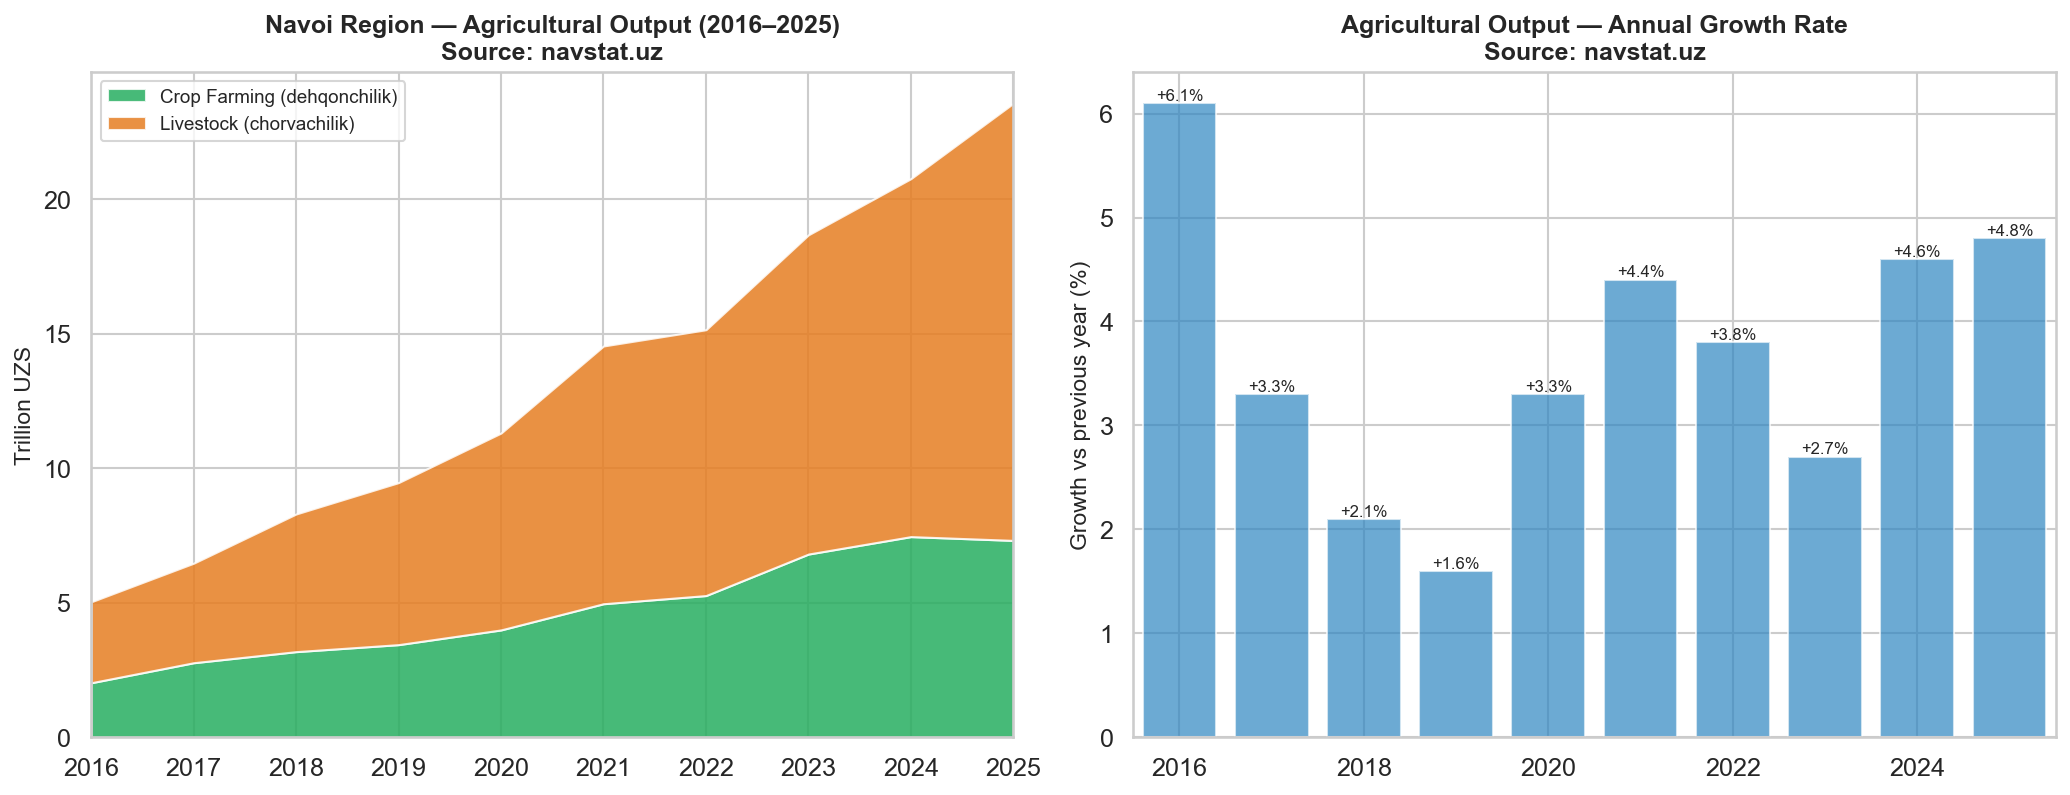

In [11]:
# --- Chart 4: Agricultural output — crop farming vs livestock (navstat.uz) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: stacked area — crop vs livestock
ax1.stackplot(econ10["year"],
              econ10["crop_T"],
              econ10["livestock_T"],
              labels=["Crop Farming (dehqonchilik)", "Livestock (chorvachilik)"],
              colors=["#27AE60", "#E67E22"], alpha=0.85)
ax1.set_ylabel("Trillion UZS", fontsize=11)
ax1.set_title("Navoi Region — Agricultural Output (2016–2025)\nSource: navstat.uz",
              fontsize=12, fontweight="bold")
ax1.legend(loc="upper left", fontsize=9)
ax1.set_xlim(2016, 2025)

# Right: year-on-year growth rate
ax2.bar(econ10["year"], econ10["growth_rate_pct"] - 100, color="#2E86C1", alpha=0.7)
ax2.axhline(0, color="black", linewidth=0.5)
ax2.set_ylabel("Growth vs previous year (%)", fontsize=11)
ax2.set_title("Agricultural Output — Annual Growth Rate\nSource: navstat.uz",
              fontsize=12, fontweight="bold")
ax2.set_xlim(2015.5, 2025.5)
for _, row in econ10.iterrows():
    val = row["growth_rate_pct"] - 100
    ax2.annotate(f"{val:+.1f}%", (row["year"], val),
                 ha="center", va="bottom" if val >= 0 else "top", fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / "task5_economy_grp.png")
plt.show()

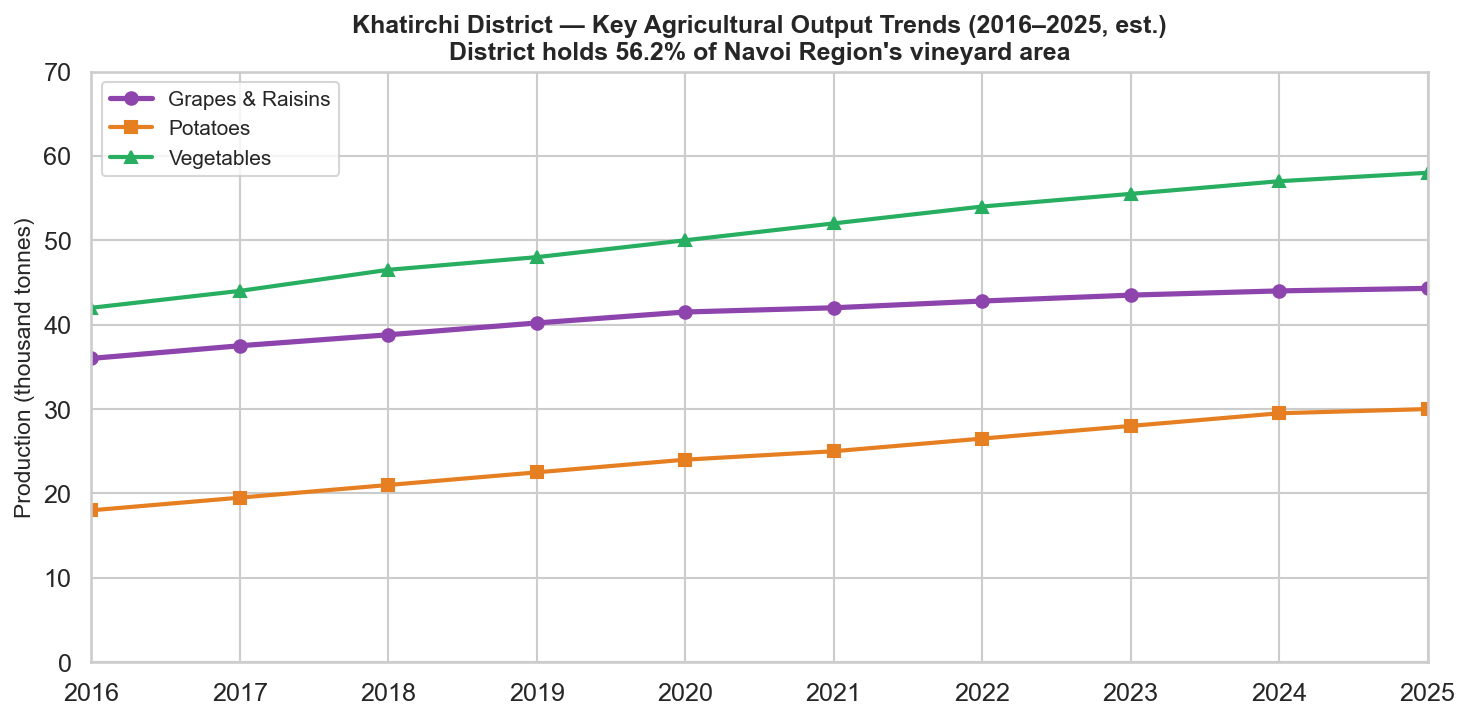

In [12]:
# --- Chart 5: Khatirchi agricultural focus — grape/raisin & horticulture ---
# Khatirchi holds 56.2% of Navoi's vineyard area and 60.9% of grape production.
# Approximate production estimates based on regional trends.
agri_years = list(range(2016, 2026))
grape_production_kt = [36.0, 37.5, 38.8, 40.2, 41.5, 42.0, 42.8, 43.5, 44.0, 44.3]
potato_production_kt = [18.0, 19.5, 21.0, 22.5, 24.0, 25.0, 26.5, 28.0, 29.5, 30.0]
vegetable_production_kt = [42.0, 44.0, 46.5, 48.0, 50.0, 52.0, 54.0, 55.5, 57.0, 58.0]

agri_df = pd.DataFrame({
    "year": agri_years,
    "Grapes & Raisins": grape_production_kt,
    "Potatoes": potato_production_kt,
    "Vegetables": vegetable_production_kt,
})

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(agri_df["year"], agri_df["Grapes & Raisins"], "o-", color="#8E44AD", linewidth=2.5, label="Grapes & Raisins")
ax.plot(agri_df["year"], agri_df["Potatoes"], "s-", color="#E67E22", linewidth=2, label="Potatoes")
ax.plot(agri_df["year"], agri_df["Vegetables"], "^-", color="#27AE60", linewidth=2, label="Vegetables")

ax.set_ylabel("Production (thousand tonnes)", fontsize=11)
ax.set_title("Khatirchi District — Key Agricultural Output Trends (2016–2025, est.)\n"
             "District holds 56.2% of Navoi Region's vineyard area",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.set_xlim(2016, 2025)
ax.set_ylim(0, 70)

plt.tight_layout()
plt.savefig(OUT_DIR / "task5_agriculture.png")
plt.show()

## Task 10 (Bonus) — Settlement Map from Geopackage

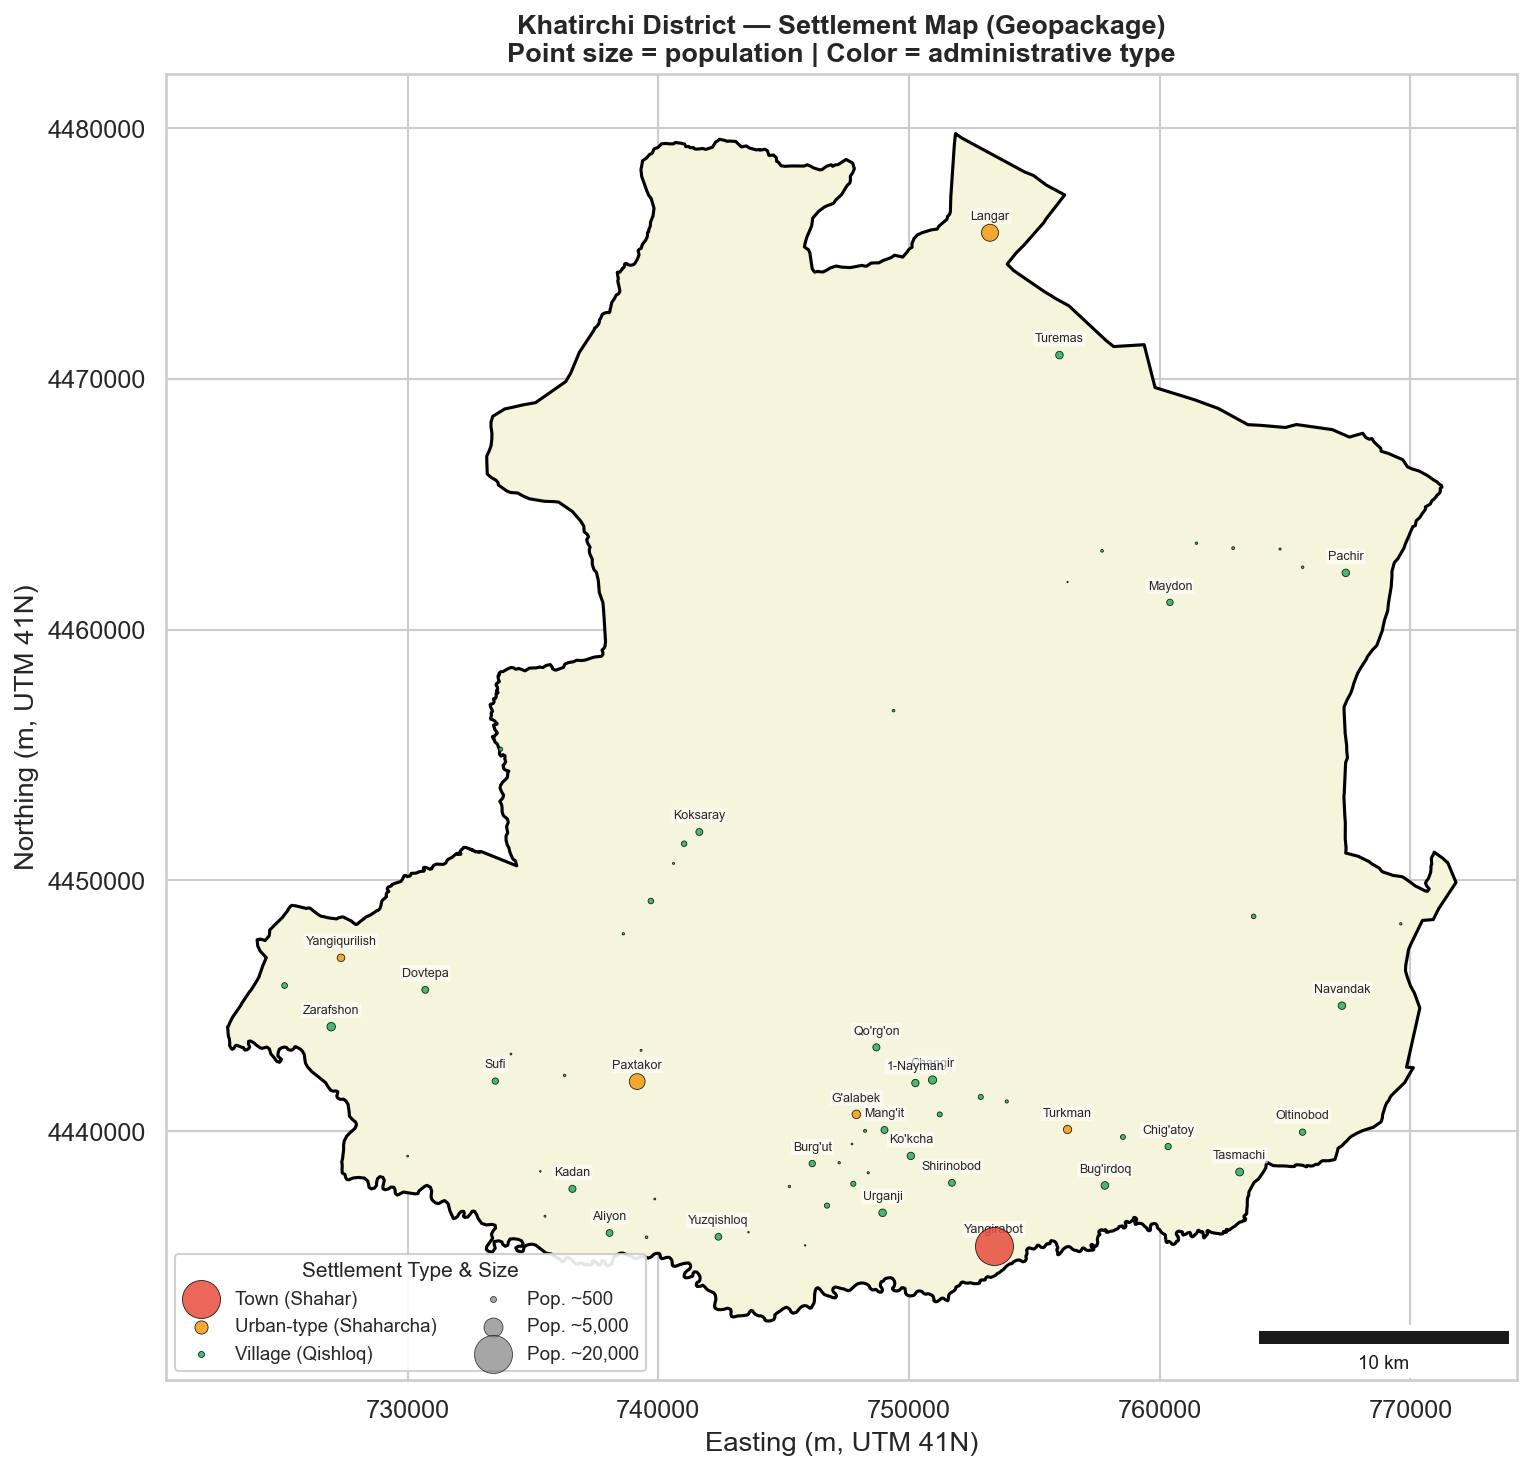


Settlements: 65 total
place
village                  59
urban type settlement     5
town                      1


In [ ]:
# --- Task 10: Settlement map from official geopackage ---
boundary = gpd.read_file("geopackage/Xatirchi_boundary.gpkg")
points = gpd.read_file("geopackage/Xatirchi_points.gpkg")
points = points.to_crs(boundary.crs)

type_colors = {
    "town": "#E74C3C",
    "urban type settlement": "#F39C12",
    "village": "#27AE60",
}
type_labels = {
    "town": "Town (Shahar)",
    "urban type settlement": "Urban-type (Shaharcha)",
    "village": "Village (Qishloq)",
}

fig, ax = plt.subplots(figsize=(12, 10))
boundary.plot(ax=ax, color="#F5F5DC", edgecolor="black", linewidth=1.5)

for place_type, color in type_colors.items():
    subset = points[points["place"] == place_type]
    if len(subset) == 0:
        continue
    sizes = subset["Inhabitants"] / 60
    subset.plot(ax=ax, color=color, markersize=sizes,
                edgecolor="black", linewidth=0.4, alpha=0.85,
                label=type_labels[place_type], zorder=5)

for _, row in points.iterrows():
    if row["Inhabitants"] > 500:
        ax.annotate(
            row["name"], xy=(row.geometry.x, row.geometry.y),
            fontsize=6, ha="center", va="bottom",
            xytext=(0, 5), textcoords="offset points",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.6, edgecolor="none"),
        )

for pop_val, label in [(500, "500"), (5000, "5,000"), (20000, "20,000")]:
    ax.scatter([], [], s=pop_val / 60, c="grey", edgecolor="black",
               linewidth=0.4, alpha=0.7, label=f"Pop. ~{label}")

ax.legend(title="Settlement Type & Size", loc="lower left", fontsize=9,
          title_fontsize=10, framealpha=0.9, ncol=2)

scalebar = ScaleBar(1, location="lower right", length_fraction=0.2,
                    font_properties={"size": 9})
ax.add_artist(scalebar)

ax.set_title("Khatirchi District — Settlement Map\n"
             "Point size = population | Color = administrative type",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Easting (m, UTM 41N)")
ax.set_ylabel("Northing (m, UTM 41N)")
ax.ticklabel_format(style="plain")

plt.tight_layout()
plt.savefig(OUT_DIR / "task10_bonus_map.png", dpi=200)
plt.show()

print(f"\nSettlements: {len(points)} total")
print(points["place"].value_counts().to_string())